In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pycreackdb/Segmentation/Ground truth/173.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/248.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/94.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/236.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/340.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/48.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/350.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/314.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/227.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/238.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/61.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/222.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/330.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/278.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/303.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/37.png
/kaggle/input/pycreackdb/Segmentation/Ground truth/231.png
/

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# 2. DATA LOADING
data_dir = "/kaggle/input/pycreackdb/Classification"
img_size = (224,224)
batch_size = 32
seed = 42


full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int",
    shuffle=True
)


total_batches = tf.data.experimental.cardinality(full_ds).numpy()
test_size = total_batches // 5
test_ds = full_ds.take(test_size)
train_ds = full_ds.skip(test_size)


train_ds = train_ds.map(lambda x, y: (x/255.0, y)).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (x/255.0, y)).prefetch(tf.data.AUTOTUNE)

class_names = full_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Num Classes:", num_classes)


Found 569 files belonging to 2 classes.
Classes: ['With crack', 'Without crack']
Num Classes: 2


In [7]:
# 3.CUSTOM CNN MODEL 

model = models.Sequential([
    layers.Input(shape=(224,224,3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 32)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,690 (49.36 MB)

 Trainable params: 12,938,690 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 4. COMPILE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# 5. TRAIN WITH EARLY STOPPING 

early_stop = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5173 - loss: 1.8382 - val_accuracy: 0.5833 - val_loss: 0.6434
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6517 - loss: 0.6086 - val_accuracy: 0.8229 - val_loss: 0.5784
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7541 - loss: 0.5706 - val_accuracy: 0.6771 - val_loss: 0.5541
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6628 - loss: 0.5769 - val_accuracy: 0.7083 - val_loss: 0.4852
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6970 - loss: 0.5682 - val_accuracy: 0.7292 - val_loss: 0.4899
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7641 - loss: 0.4852 - val_accuracy: 0.8750 - val_loss: 0.3702
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7132 - loss: 0.5488 - val_accuracy: 0.8125 - val_loss: 0.3769
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7409 - loss: 0.4867 - val_accuracy: 0.8229 - val_loss:

In [10]:
# 6. EVALUATION

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

# Predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 580ms/step - accuracy: 0.9570 - loss: 0.1163
Test Accuracy: 0.96875
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step

Classification Report:

               precision    recall  f1-score   support

   With crack       0.97      0.97      0.97        61
Without crack       0.94      0.94      0.94        35

     accuracy                           0.96        96
    macro avg       0.96      0.96      0.96        96
 weighted avg       0.96      0.96      0.96        96


Confusion Matrix:
 [[59  2]
 [ 2 33]]


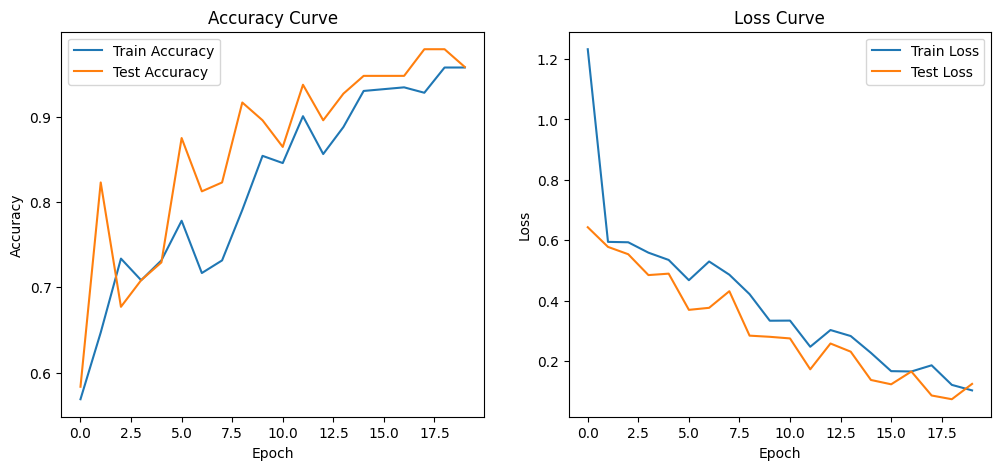

In [11]:
# 7. PLOT ACCURACY & LOSS

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()